# Trigonometry

Trigonometric functions relate **angles** to **ratios of sides** in a right triangle and extend naturally to the **unit circle** ($r=1$).

An angle $\theta$ can be measured in **degrees** ($0°$–$360°$) or **radians** ($0$–$2\pi$). Conversion: $\theta_{\text{rad}} = \theta_{\text{deg}} \cdot \frac{\pi}{180}$.


## Angles and the Unit Circle

On the unit circle centred at the origin, a point at angle $\theta$ from the positive $x$-axis has coordinates $(\cos\theta,\;\sin\theta)$.

One full revolution: $360° = 2\pi$ rad. &ensp; A **right angle**: $90° = \frac{\pi}{2}$ rad.


In [1]:
%matplotlib inline
import numpy as np, matplotlib.pyplot as plt, ipywidgets as widgets
from IPython.display import display
from matplotlib.patches import Arc

def plot_angle(angle_deg):
    theta = np.radians(angle_deg)
    t = np.linspace(0, 2 * np.pi, 300)

    fig, (ax_circ, ax_bar) = plt.subplots(1, 2, figsize=(9, 4),
                                           gridspec_kw={'width_ratios': [1, 1.2]})
    # Unit circle
    ax_circ.plot(np.cos(t), np.sin(t), 'k', lw=1)
    ax_circ.plot([0, np.cos(theta)], [0, np.sin(theta)], 'gray', lw=1.5)
    ax_circ.plot(np.cos(theta), np.sin(theta), 'ro', ms=7)
    arc = Arc((0, 0), 0.4, 0.4, angle=0, theta1=0, theta2=angle_deg,
              color='steelblue', lw=2)
    ax_circ.add_patch(arc)
    ax_circ.set(xlim=(-1.3, 1.3), ylim=(-1.3, 1.3), aspect='equal')
    ax_circ.axhline(0, color='k', lw=0.4); ax_circ.axvline(0, color='k', lw=0.4)
    ax_circ.grid(True, alpha=0.3)
    ax_circ.set_title(f'Unit circle — {angle_deg:.0f}° = {theta:.2f} rad')

    # Bar comparison degrees vs radians
    ax_bar.barh(['Degrees', 'Radians'], [angle_deg / 360, theta / (2 * np.pi)],
                color=['#4c72b0', '#dd8452'], height=0.4)
    ax_bar.set_xlim(0, 1)
    ax_bar.set_xlabel('Fraction of full revolution')
    ax_bar.set_title(f'{angle_deg:.0f}°  ↔  {theta:.3f} rad')
    plt.tight_layout(); plt.show()

w = widgets.FloatSlider(value=45, min=0, max=360, step=1, description='Angle (°)')
display(w, widgets.interactive_output(plot_angle, {'angle_deg': w}))


FloatSlider(value=45.0, description='Angle (°)', max=360.0, step=1.0)

Output()

## The Right Triangle

In a right triangle with acute angle $\alpha$:

$$\sin\alpha = \frac{\text{opposite}}{\text{hypotenuse}},\quad
\cos\alpha = \frac{\text{adjacent}}{\text{hypotenuse}},\quad
\tan\alpha = \frac{\text{opposite}}{\text{adjacent}} = \frac{\sin\alpha}{\cos\alpha}$$

**Pythagorean identity:** $\sin^2\alpha + \cos^2\alpha = 1$.


Output()

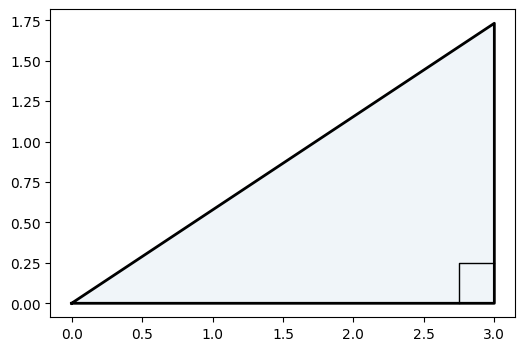

In [ ]:
%matplotlib inline
import numpy as np, matplotlib.pyplot as plt, ipywidgets as widgets
from IPython.display import display
from matplotlib.patches import Arc

def plot_triangle(angle_deg, adj):
    alpha = np.radians(angle_deg)
    opp = adj * np.tan(alpha)
    hyp = adj / np.cos(alpha)

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot([0, adj, adj, 0], [0, 0, opp, 0], 'k-', lw=2)
    ax.fill([0, adj, adj], [0, 0, opp], alpha=0.08, color='steelblue')
    # right-angle square
    sq = 0.25
    ax.plot([adj - sq, adj - sq, adj], [0, sq, sq], 'k', lw=1)
    arc = Arc((0, 0), 1.2, 1.2, angle=0, theta1=0, theta2=angle_deg, color='steelblue', lw=2)
    ax.add_patch(arc)
    # labels
    ax.text(adj / 2, -0.3, f'adj = {adj:.1f}', ha='center', color='green', fontsize=10)
    ax.text(adj + 0.2, opp / 2, f'opp = {opp:.2f}', va='center', color='red', fontsize=10)
    ax.text(adj / 2 - 0.5, opp / 2 + 0.2, f'hyp = {hyp:.2f}', rotation=np.degrees(np.arctan2(opp, adj)),
            color='blue', fontsize=10)
    ax.set(aspect='equal', xlim=(-0.5, adj + 1.5), ylim=(-0.8, opp + 0.8))
    ax.grid(True, alpha=0.3)
    ax.set_title(f'α = {angle_deg:.0f}°  |  sin={np.sin(alpha):.3f}  cos={np.cos(alpha):.3f}  tan={np.tan(alpha):.3f}')
    plt.tight_layout(); plt.show()

wa = widgets.FloatSlider(value=30, min=5, max=85, step=1, description='α (°)')
wl = widgets.FloatSlider(value=3, min=1, max=5, step=0.1, description='adjacent')
display(widgets.VBox([wa, wl]),
        widgets.interactive_output(plot_triangle, {'angle_deg': wa, 'adj': wl}))


## Sine — from Circle to Wave

As $\theta$ sweeps around the unit circle, the $y$-coordinate traces out the **sine wave**.

$$\sin\theta = y\text{-coordinate on the unit circle}$$

The projection from the circle to the graph makes the connection between circular motion and oscillation visible.


In [8]:
%matplotlib inline
import numpy as np, matplotlib.pyplot as plt, ipywidgets as widgets
from IPython.display import display
from matplotlib.patches import Arc

def plot_sine_def(angle_deg):
    theta = np.radians(angle_deg)
    t = np.linspace(0, 2 * np.pi, 500)

    fig, (ax_c, ax_s) = plt.subplots(1, 2, figsize=(10, 4))
    # Circle
    ax_c.plot(np.cos(t), np.sin(t), 'k', lw=1)
    ax_c.plot([0, np.cos(theta)], [0, np.sin(theta)], 'gray', lw=1.5)
    ax_c.plot([np.cos(theta), np.cos(theta)], [0, np.sin(theta)], 'r--', lw=1.5)
    ax_c.plot(np.cos(theta), np.sin(theta), 'ro', ms=7)
    arc = Arc((0, 0), 0.5, 0.5, angle=0, theta1=0, theta2=angle_deg, color='steelblue', lw=2)
    ax_c.add_patch(arc)
    ax_c.set(xlim=(-1.4, 1.4), ylim=(-1.4, 1.4), aspect='equal', title='Unit Circle')
    ax_c.axhline(0, color='k', lw=0.4); ax_c.axvline(0, color='k', lw=0.4)
    ax_c.grid(True, alpha=0.3)

    # Sine wave
    ax_s.plot(t, np.sin(t), 'b', lw=1.5)
    ax_s.plot([theta, theta], [0, np.sin(theta)], 'r--', lw=1.5)
    ax_s.plot(theta, np.sin(theta), 'ro', ms=7)
    ax_s.set(xlim=(0, 2 * np.pi), ylim=(-1.3, 1.3),
             xlabel='θ (rad)', ylabel='sin θ',
             title=f'sin({angle_deg:.0f}°) = {np.sin(theta):.3f}')
    ax_s.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

w = widgets.FloatSlider(value=0, min=0, max=360, step=1, description='θ (°)')
display(w, widgets.interactive_output(plot_sine_def, {'angle_deg': w}))


FloatSlider(value=0.0, description='θ (°)', max=360.0, step=1.0)

Output()

## Cosine — from Circle to Wave

The $x$-coordinate on the unit circle traces the **cosine wave**.

$$\cos\theta = x\text{-coordinate on the unit circle}$$

Note that $\cos\theta = \sin\!\left(\theta + \frac{\pi}{2}\right)$: cosine is a phase-shifted sine.


In [ ]:
%matplotlib inline
import numpy as np, matplotlib.pyplot as plt, ipywidgets as widgets
from IPython.display import display
from matplotlib.patches import Arc

def plot_cos_def(angle_deg):
    theta = np.radians(angle_deg)
    t = np.linspace(0, 2 * np.pi, 500)

    fig, (ax_c, ax_w) = plt.subplots(1, 2, figsize=(10, 4))
    ax_c.plot(np.cos(t), np.sin(t), 'k', lw=1)
    ax_c.plot([0, np.cos(theta)], [0, np.sin(theta)], 'gray', lw=1.5)
    ax_c.plot([0, np.cos(theta)], [0, 0], 'r--', lw=1.5)
    ax_c.plot(np.cos(theta), np.sin(theta), 'ro', ms=7)
    arc = Arc((0, 0), 0.5, 0.5, angle=0, theta1=0, theta2=angle_deg, color='steelblue', lw=2)
    ax_c.add_patch(arc)
    ax_c.set(xlim=(-1.4, 1.4), ylim=(-1.4, 1.4), aspect='equal', title='Unit Circle')
    ax_c.axhline(0, color='k', lw=0.4); ax_c.axvline(0, color='k', lw=0.4)
    ax_c.grid(True, alpha=0.3)

    ax_w.plot(t, np.cos(t), 'b', lw=1.5)
    ax_w.plot([theta, theta], [0, np.cos(theta)], 'r--', lw=1.5)
    ax_w.plot(theta, np.cos(theta), 'ro', ms=7)
    ax_w.set(xlim=(0, 2 * np.pi), ylim=(-1.3, 1.3),
             xlabel='θ (rad)', ylabel='cos θ',
             title=f'cos({angle_deg:.0f}°) = {np.cos(theta):.3f}')
    ax_w.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

w = widgets.FloatSlider(value=0, min=0, max=360, step=1, description='θ (°)')
display(w, widgets.interactive_output(plot_cos_def, {'angle_deg': w}))


FloatSlider(value=0.0, description='θ (°)', max=360.0, step=1.0)

Output()

## Tangent — from Circle to Wave

$$\tan\theta = \frac{\sin\theta}{\cos\theta}$$

Geometrically, $\tan\theta$ is the length of the segment on the **tangent line** to the circle at $(1, 0)$, from the $x$-axis to the intersection with the extended radius.

The tangent has **vertical asymptotes** wherever $\cos\theta = 0$ (i.e. $\theta = \frac{\pi}{2} + k\pi$).


FloatSlider(value=0.0, description='θ (°)', max=360.0, step=1.0)

Output()

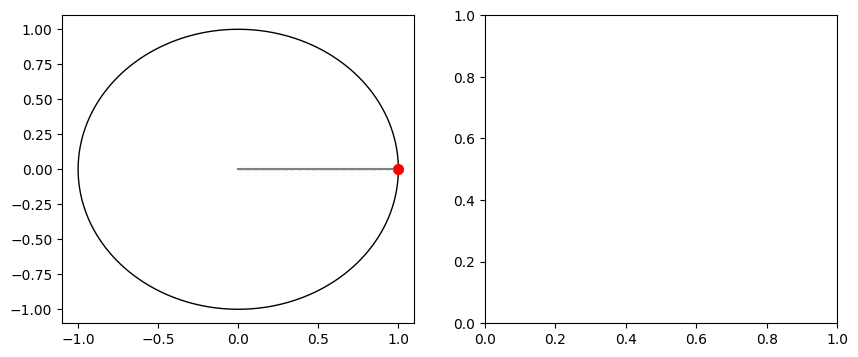

In [ ]:
%matplotlib inline
import numpy as np, matplotlib.pyplot as plt, ipywidgets as widgets
from IPython.display import display
from matplotlib.patches import Arc

def plot_tan_def(angle_deg):
    theta = np.radians(angle_deg)
    t = np.linspace(0, 2 * np.pi, 500)
    tan_vals = np.tan(t)
    tan_vals[np.abs(np.diff(np.append(tan_vals, tan_vals[-1]))) > 5] = np.nan

    fig, (ax_c, ax_w) = plt.subplots(1, 2, figsize=(10, 4))
    ax_c.plot(np.cos(t), np.sin(t), 'k', lw=1)
    ax_c.plot([0, np.cos(theta)], [0, np.sin(theta)], 'gray', lw=1.5)
    tan_val = np.tan(theta) if abs(np.cos(theta)) > 0.01 else np.nan
    if np.isfinite(tan_val) and abs(tan_val) < 6:
        ax_c.plot([1, 1], [0, tan_val], 'r-', lw=2)
        ax_c.plot(1, tan_val, 'ro', ms=7)
        ax_c.plot([0, 1], [0, tan_val], 'gray', ls='--', lw=1)
    ax_c.plot(np.cos(theta), np.sin(theta), 'ro', ms=5)
    arc = Arc((0, 0), 0.5, 0.5, angle=0, theta1=0, theta2=angle_deg, color='steelblue', lw=2)
    ax_c.add_patch(arc)
    ax_c.set(xlim=(-1.5, 2), ylim=(-3, 3), aspect='equal', title='Unit Circle + Tangent line x=1')
    ax_c.axhline(0, color='k', lw=0.4); ax_c.axvline(0, color='k', lw=0.4)
    ax_c.grid(True, alpha=0.3)

    ax_w.plot(t, tan_vals, 'b', lw=1.5)
    if np.isfinite(tan_val):
        ax_w.plot(theta, tan_val, 'ro', ms=7)
        ax_w.plot([theta, theta], [0, tan_val], 'r--', lw=1.5)
    ax_w.set(xlim=(0, 2 * np.pi), ylim=(-5, 5),
             xlabel='θ (rad)', ylabel='tan θ',
             title=f'tan({angle_deg:.0f}°) = {tan_val:.3f}' if np.isfinite(tan_val) else 'tan → ±∞')
    ax_w.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

w = widgets.FloatSlider(value=0, min=0, max=360, step=1, description='θ (°)')
display(w, widgets.interactive_output(plot_tan_def, {'angle_deg': w}))


## Parametric Trigonometric Functions

The general forms with **amplitude** $a$, **angular frequency** $\omega$, **phase** $\varphi$ and **vertical offset** $c$:

$$y = a\sin(\omega x + \varphi) + c \qquad y = a\cos(\omega x + \varphi) + c \qquad y = a\tan(\omega x) + c$$

| Parameter | Effect |
|-----------|--------|
| $a$ | amplitude (vertical stretch) |
| $\omega$ | angular frequency → period $T = 2\pi/\omega$ |
| $\varphi$ | phase shift (horizontal translation) |
| $c$ | vertical offset |


In [ ]:
%matplotlib inline
import numpy as np, matplotlib.pyplot as plt, ipywidgets as widgets
from IPython.display import display

def plot_trig(func, a, omega, phi, c):
    x = np.linspace(0, 4 * np.pi, 800)
    fn = {'sin': np.sin, 'cos': np.cos, 'tan': np.tan}[func]
    y = a * fn(omega * x + phi) + c
    if func == 'tan':
        y[np.abs(np.diff(np.append(y, y[-1]))) > 10] = np.nan

    fig, ax = plt.subplots(figsize=(7, 3.5))
    ax.plot(x, y, lw=2)
    ax.axhline(c, color='gray', ls='--', lw=0.8, label=f'offset c={c:.1f}')
    ax.axhline(0, color='k', lw=0.4)
    ylim = max(abs(a) + abs(c) + 1, 5) if func != 'tan' else 8
    ax.set(xlim=(0, 4 * np.pi), ylim=(-ylim, ylim), xlabel='x', ylabel='f(x)')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    period = 2 * np.pi / abs(omega) if omega != 0 else np.inf
    ax.set_title(f'{func}: a={a:.1f}  ω={omega:.1f}  φ={phi:.1f}  c={c:.1f}  |  T={period:.2f}')
    plt.tight_layout(); plt.show()

wf = widgets.Dropdown(options=['sin', 'cos', 'tan'], value='sin', description='Function')
wa = widgets.FloatSlider(value=1, min=-3, max=3, step=0.1, description='a (ampl.)')
wo = widgets.FloatSlider(value=1, min=-3, max=3, step=0.1, description='ω (freq.)')
wp = widgets.FloatSlider(value=0, min=-3.14, max=3.14, step=0.05, description='φ (phase)')
wcc = widgets.FloatSlider(value=0, min=-3, max=3, step=0.1, description='c (offset)')
ui = widgets.VBox([wf, wa, wo, wp, wcc])
out = widgets.interactive_output(plot_trig, {'func': wf, 'a': wa, 'omega': wo, 'phi': wp, 'c': wcc})
display(ui, out)


Output()